# Exp2 dataset generation

1. We build the artificial initial stream function from `main.tex`:
   `psi(t=0) = P_1^1(sin(phi)) cos(lambda) + P_2^1(sin(phi)) cos(lambda)`  
   on a `100 x 200` global grid.

2. We compute the initial vorticity with:
   `zeta = Laplacian(psi)`  
   using a spectral Laplacian for numerical stability.

3. We evolve this initial vorticity with the spectral BVE/SEM solver using:
   `r = 1`, `Omega = 1`, `dt = 0.001`, triangular truncation, and Robert smoothing.

4. We save snapshots at:
   `t = 0.0, 0.3, ..., 3.0`  
   giving `11` time steps.

5. We downsample the SEM fields to the paper DQC grid:
   `14 lat x 25 lon`.

Final dataset:
`exp2_artificial_dataset_clean.npz`

with:
`psi_sem.shape = (11, 14, 25)`  
`zeta_sem.shape = (11, 14, 25)`

In [37]:
import numpy as np
from scipy.special import lpmv
from datetime import datetime

from barotropic.pyspharm_transforms import TransformsEngine


OMEGA = 1.0
RADIUS = 1.0

N_LAT_FULL = 100
N_LON_FULL = 200

N_LAT_FINAL = 14
N_LON_FINAL = 25

SEM_DT = 0.001
T_MAX = 3.0
SNAPSHOT_INTERVAL = 0.3

OUTPUT_PATH = "exp2_artificial_dataset.npz"

In [38]:
import numpy as np
from scipy.special import lpmv
from barotropic.pyspharm_transforms import TransformsEngine

N_LAT_FULL = 100
N_LON_FULL = 200
TRUNCATION = N_LON_FULL // 3
RADIUS = 1.0

lat_full_deg = np.linspace(90.0, -90.0, N_LAT_FULL)
lon_full_deg = np.linspace(0.0, 360.0 - 360.0 / N_LON_FULL, N_LON_FULL)

lat_rad = np.deg2rad(lat_full_deg)
lon_rad = np.deg2rad(lon_full_deg)

LAT, LON = np.meshgrid(lat_rad, lon_rad, indexing="ij")

psi0 = (
    lpmv(1, 1, np.sin(LAT)) * np.cos(LON)
    + lpmv(1, 2, np.sin(LAT)) * np.cos(LON)
)

engine = TransformsEngine(
    N_LON_FULL,
    N_LAT_FULL,
    TRUNCATION,
    radius=RADIUS,
)

psi0_spec = engine.grid_to_spec(psi0)

# True spherical Laplacian eigenvalue is -n(n+1), with n = wavenumbers[1] (the degree).
n_deg = engine.wavenumbers[1].astype(float)
factor = -n_deg * (n_deg + 1.0) / (RADIUS ** 2)

zeta0 = engine.spec_to_grid(factor * psi0_spec)

print("lat:", lat_full_deg[0], "to", lat_full_deg[-1])
print("lon:", lon_full_deg[0], "to", lon_full_deg[-1])
print("psi0:", psi0.shape, psi0.min(), psi0.max())
print("zeta0:", zeta0.shape, zeta0.min(), zeta0.max())
print("finite:", np.isfinite(psi0).all(), np.isfinite(zeta0).all())

lat: 90.0 to -90.0
lon: 0.0 to 358.2
psi0: (100, 200) -2.244350133613925 2.244350133613925
zeta0: (100, 200) -10.441047 10.440586
finite: True True


In [39]:
# ============================================================
# CELL 2 — SEM evolution from zeta0
# Paper: feed initial vorticity to SEM, evolve with dt=0.001,
# save psi and zeta every 0.3 up to t=3.
# ============================================================

class UnitSphereBVEFromZeta:
    def __init__(
        self,
        zeta_initial,
        truncation,
        dt,
        omega=1.0,
        radius=1.0,
        robert_coefficient=0.04,
        damping_coefficient=1e-4,
        damping_order=4,
    ):
        self.nlat, self.nlon = zeta_initial.shape
        self.truncation = truncation
        self.dt = dt
        self.omega = omega
        self.radius = radius
        self.robert_coefficient = robert_coefficient

        self.engine = TransformsEngine(
            self.nlon,
            self.nlat,
            truncation,
            radius=radius,
        )

        m, n = self.engine.wavenumbers
        # True spherical Laplacian eigenvalue magnitude is n(n+1).
        # getspecindx returns n as the spherical-harmonic degree already.
        ell = n.astype(float) * (n.astype(float) + 1.0) / float(radius) ** 2
        self.damping = damping_coefficient * (ell / ell[truncation]) ** damping_order

        # Same regular latitude order as psi0/zeta0: north -> south.
        lats = np.linspace(90.0, -90.0, self.nlat)
        self.f = 2.0 * omega * np.sin(np.deg2rad(lats))[:, np.newaxis]

        self.vrt_spec = self.engine.grid_to_spec(zeta_initial)
        self.vrt_spec_prev = self.vrt_spec.copy()
        self.vrt_grid = self.engine.spec_to_grid(self.vrt_spec)

        self.psi_grid = self.engine.spec_to_grid(self.vrt_to_psi_spec(self.vrt_spec))

        self.u_grid, self.v_grid = self.engine.uv_grid_from_vrtdiv_spec(
            self.vrt_spec,
            np.zeros_like(self.vrt_spec),
        )

        self.t = 0.0
        self.first_step = True

    def vrt_to_psi_spec(self, vrt_spec):
        # True inverse spherical Laplacian 1/(-n(n+1)); n=0 mean mode set to 0.
        n_deg = self.engine.wavenumbers[1].astype(float)
        eigen = -n_deg * (n_deg + 1.0) / (self.radius ** 2)
        inv = np.zeros_like(eigen)
        nonzero = n_deg > 0
        inv[nonzero] = 1.0 / eigen[nonzero]
        return vrt_spec * inv

    def step_forward(self):
        dt = self.dt if self.first_step else 2.0 * self.dt

        # Same structure as the barotropic vorticity core:
        # evolves absolute vorticity through non-divergent velocity.
        dudt = -(self.f + self.vrt_grid) * self.v_grid
        dvdt = (self.f + self.vrt_grid) * self.u_grid

        dzetadt, _ = self.engine.vrtdiv_spec_from_uv_grid(dudt, dvdt)

        coeffs = 1.0 / (1.0 + self.damping * self.dt)
        dzetadt = coeffs * (dzetadt - self.damping * self.vrt_spec_prev)

        if self.first_step:
            new_vrt_spec = self.vrt_spec + dt * dzetadt
            self.vrt_spec[:] += self.robert_coefficient * (
                new_vrt_spec - self.vrt_spec
            )
            self.first_step = False
        else:
            self.vrt_spec[:] += self.robert_coefficient * (
                self.vrt_spec_prev - 2.0 * self.vrt_spec
            )
            new_vrt_spec = self.vrt_spec_prev + dt * dzetadt
            self.vrt_spec[:] += self.robert_coefficient * new_vrt_spec

        self.vrt_spec_prev[:] = self.vrt_spec
        self.vrt_spec[:] = new_vrt_spec

        self.vrt_grid[:] = self.engine.spec_to_grid(self.vrt_spec)
        self.psi_grid[:] = self.engine.spec_to_grid(
            self.vrt_to_psi_spec(self.vrt_spec)
        )

        self.u_grid[:], self.v_grid[:] = self.engine.uv_grid_from_vrtdiv_spec(
            self.vrt_spec,
            np.zeros_like(self.vrt_spec),
        )

        self.t += self.dt


SEM_DT = 0.001
SNAPSHOT_INTERVAL = 0.3
T_MAX = 3.0

model = UnitSphereBVEFromZeta(
    zeta_initial=zeta0,
    truncation=TRUNCATION,
    dt=SEM_DT,
    omega=1.0,
    radius=1.0,
)

psi_full = [model.psi_grid.copy()]
zeta_full = [model.vrt_grid.copy()]
times = [0.0]

steps_per_snapshot = int(round(SNAPSHOT_INTERVAL / SEM_DT))
n_snapshots = int(round(T_MAX / SNAPSHOT_INTERVAL))

for snapshot in range(1, n_snapshots + 1):
    for _ in range(steps_per_snapshot):
        model.step_forward()

    t = round(snapshot * SNAPSHOT_INTERVAL, 10)

    psi_full.append(model.psi_grid.copy())
    zeta_full.append(model.vrt_grid.copy())
    times.append(t)

    print(
        f"snapshot {snapshot:02d}/{n_snapshots} | t={t:.1f} | "
        f"psi=[{model.psi_grid.min():.4e}, {model.psi_grid.max():.4e}] | "
        f"zeta=[{model.vrt_grid.min():.4e}, {model.vrt_grid.max():.4e}]"
    )

psi_full = np.asarray(psi_full)
zeta_full = np.asarray(zeta_full)
times = np.asarray(times)

print("psi_full:", psi_full.shape)
print("zeta_full:", zeta_full.shape)
print("times:", times)

assert psi_full.shape == (11, 100, 200)
assert zeta_full.shape == (11, 100, 200)
assert times.shape == (11,)
assert np.isfinite(psi_full).all()
assert np.isfinite(zeta_full).all()

print("CELL 2 PASSED")

snapshot 01/10 | t=0.3 | psi=[-2.2462e+00, 2.2215e+00] | zeta=[-1.0388e+01, 1.0443e+01]
snapshot 02/10 | t=0.6 | psi=[-2.2528e+00, 2.1546e+00] | zeta=[-1.0235e+01, 1.0446e+01]
snapshot 03/10 | t=0.9 | psi=[-2.2606e+00, 2.0462e+00] | zeta=[-9.9915e+00, 1.0451e+01]
snapshot 04/10 | t=1.2 | psi=[-2.2684e+00, 1.9020e+00] | zeta=[-9.6710e+00, 1.0460e+01]
snapshot 05/10 | t=1.5 | psi=[-2.2733e+00, 1.7294e+00] | zeta=[-9.3007e+00, 1.0465e+01]
snapshot 06/10 | t=1.8 | psi=[-2.2737e+00, 1.7091e+00] | zeta=[-9.2589e+00, 1.0465e+01]
snapshot 07/10 | t=2.1 | psi=[-2.2691e+00, 1.8849e+00] | zeta=[-9.6340e+00, 1.0460e+01]
snapshot 08/10 | t=2.4 | psi=[-2.2616e+00, 2.0324e+00] | zeta=[-9.9581e+00, 1.0451e+01]
snapshot 09/10 | t=2.7 | psi=[-2.2535e+00, 2.1444e+00] | zeta=[-1.0212e+01, 1.0446e+01]
snapshot 10/10 | t=3.0 | psi=[-2.2465e+00, 2.2163e+00] | zeta=[-1.0375e+01, 1.0442e+01]
psi_full: (11, 100, 200)
zeta_full: (11, 100, 200)
times: [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
CELL 2 PASSED


In [40]:
# ============================================================
# CELL 3 — Downsample to DQC training grid and save dataset
# Paper: final DQC grid = 14 latitude x 25 longitude x 11 time.
# ============================================================

N_LAT_FINAL = 14
N_LON_FINAL = 25

lat_idx = np.linspace(0, N_LAT_FULL - 1, N_LAT_FINAL).round().astype(int)
lon_idx = np.linspace(0, N_LON_FULL - 1, N_LON_FINAL).round().astype(int)

psi_sem = psi_full[:, lat_idx][:, :, lon_idx]
zeta_sem = zeta_full[:, lat_idx][:, :, lon_idx]

lat_deg = lat_full_deg[lat_idx]
lon_deg = lon_full_deg[lon_idx]

print("psi_sem:", psi_sem.shape)
print("zeta_sem:", zeta_sem.shape)
print("lat_deg:", lat_deg[0], "to", lat_deg[-1])
print("lon_deg:", lon_deg[0], "to", lon_deg[-1])
print("times:", times)

assert psi_sem.shape == (11, 14, 25)
assert zeta_sem.shape == (11, 14, 25)
assert times.shape == (11,)
assert np.isfinite(psi_sem).all()
assert np.isfinite(zeta_sem).all()

OUTPUT_PATH = "exp2_artificial_dataset_clean.npz"

np.savez(
    OUTPUT_PATH,
    psi_sem=psi_sem,
    zeta_sem=zeta_sem,
    times=times,
    lat_deg=lat_deg,
    lon_deg=lon_deg,
    psi_full=psi_full,
    zeta_full=zeta_full,
    lat_full_deg=lat_full_deg,
    lon_full_deg=lon_full_deg,
)

print("saved:", OUTPUT_PATH)
print

psi_sem: (11, 14, 25)
zeta_sem: (11, 14, 25)
lat_deg: 90.0 to -90.0
lon_deg: 0.0 to 358.2
times: [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
saved: exp2_artificial_dataset_clean.npz


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

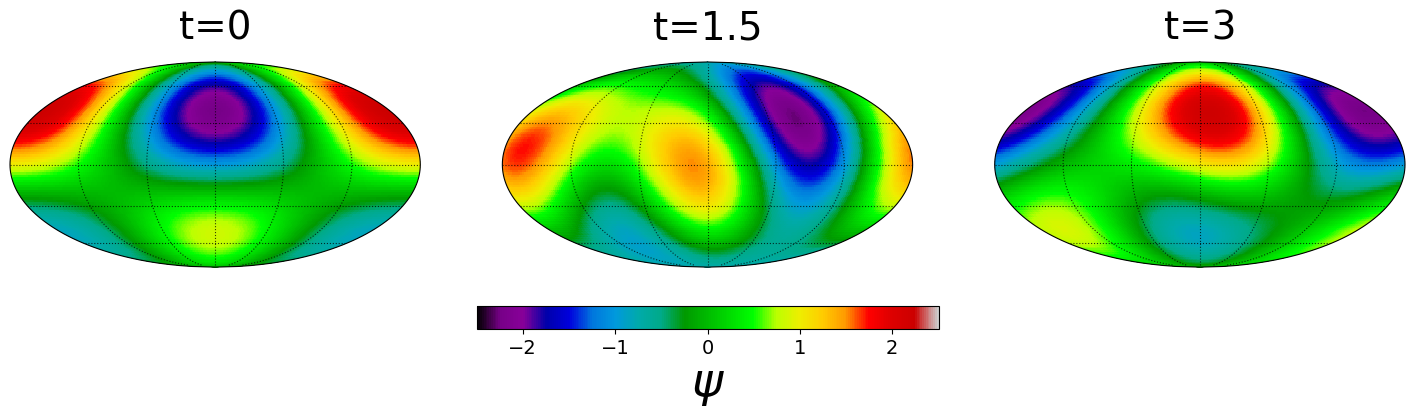

In [43]:
# ============================================================
# CELL 4 — Visual check against paper figure
# SEM psi at t=0, 1.5, 3.0
# ============================================================

import os
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

os.makedirs("images", exist_ok=True)

data = np.load("exp2_artificial_dataset_clean.npz")

psi_plot = data["psi_full"]
times_plot = data["times"]
lat_plot = data["lat_full_deg"]
lon_plot = data["lon_full_deg"]

# Sort latitude south -> north for Cartopy plotting only.
lat_sort = np.argsort(lat_plot)
lat_sorted = lat_plot[lat_sort]
psi_sorted = psi_plot[:, lat_sort, :]

# Wrap longitudes for projection.
lon_wrapped = ((lon_plot + 180) % 360) - 180
lon_sort = np.argsort(lon_wrapped)
lon_sorted = lon_wrapped[lon_sort]
psi_sorted = psi_sorted[:, :, lon_sort]

lon_grid, lat_grid = np.meshgrid(lon_sorted, lat_sorted)

target_times = [0.0, 1.5, 3.0]
target_indices = [int(np.argmin(np.abs(times_plot - t))) for t in target_times]

projection = ccrs.Mollweide(central_longitude=0)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 5))
axes = []

for i, (idx, t) in enumerate(zip(target_indices, target_times), start=1):
    ax = fig.add_subplot(1, 3, i, projection=projection)
    axes.append(ax)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        psi_sorted[idx],
        transform=data_crs,
        cmap="nipy_spectral",
        vmin=-2.5,
        vmax=2.5,
        shading="auto",
    )

    ax.set_global()
    ax.gridlines(
        draw_labels=False,
        linewidth=0.8,
        color="black",
        alpha=0.75,
        linestyle=":",
    )
    ax.set_title(f"t={t:g}", fontsize=28, pad=16)

cbar = fig.colorbar(
    mesh,
    ax=axes,
    orientation="horizontal",
    fraction=0.06,
    pad=0.10,
    ticks=[-2, -1, 0, 1, 2],
)

cbar.set_label(r"$\psi$", fontsize=34)
cbar.ax.tick_params(labelsize=14)

plt.savefig("images/exp2_sem_clean_check.png", dpi=250, bbox_inches="tight")
plt.show()

In [42]:
import numpy as np

data = np.load("exp2_artificial_dataset_clean.npz")

print(data.files)

psi_sem = data["psi_sem"]
zeta_sem = data["zeta_sem"]
times = data["times"]
lat_deg = data["lat_deg"]
lon_deg = data["lon_deg"]

print("psi_sem:", psi_sem.shape, psi_sem.min(), psi_sem.max())
print("zeta_sem:", zeta_sem.shape, zeta_sem.min(), zeta_sem.max())
print("times:", times)
print("lat:", lat_deg[0], "to", lat_deg[-1])
print("lon:", lon_deg[0], "to", lon_deg[-1])

assert psi_sem.shape == (11, 14, 25)
assert zeta_sem.shape == (11, 14, 25)
assert times.shape == (11,)
assert np.allclose(times, np.arange(0.0, 3.0 + 1e-12, 0.3))
assert np.isfinite(psi_sem).all()
assert np.isfinite(zeta_sem).all()

print("EXP2 DATASET READY")

['psi_sem', 'zeta_sem', 'times', 'lat_deg', 'lon_deg', 'psi_full', 'zeta_full', 'lat_full_deg', 'lon_full_deg']
psi_sem: (11, 14, 25) -2.270353 2.2320774
zeta_sem: (11, 14, 25) -10.278162 10.364732
times: [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
lat: 90.0 to -90.0
lon: 0.0 to 358.2
EXP2 DATASET READY
